In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/tarot_data.zip" -d /content/tarot_data
!unzip -q "/content/drive/MyDrive/palm_images.zip" -d /content/palm_images

In [ ]:
import os
print(os.listdir('/content/tarot_data'))
print(os.listdir('/content/palm_images')[:10])

['cards', 'tarot-images.json']
['HandInfo.csv', 'Hands']


In [ ]:
import json
import pandas as pd

with open('/content/tarot_data/tarot-images.json') as f:
    data = json.load(f)


print(type(data))
print(data.keys() if isinstance(data, dict) else data[:1])

<class 'dict'>
dict_keys(['description', 'cards'])


In [ ]:
tarot_df = pd.json_normalize(data['cards'])

print("Rows:", tarot_df.shape[0])
print("Columns:", tarot_df.shape[1])
print(tarot_df.columns.tolist())
tarot_df.info()
tarot_df.head()

Rows: 78
Columns: 17
['name', 'number', 'arcana', 'suit', 'img', 'fortune_telling', 'keywords', 'Archetype', 'Hebrew Alphabet', 'Numerology', 'Elemental', 'Mythical/Spiritual', 'Questions to Ask', 'meanings.light', 'meanings.shadow', 'Astrology', 'Affirmation']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                78 non-null     object
 1   number              78 non-null     object
 2   arcana              78 non-null     object
 3   suit                78 non-null     object
 4   img                 78 non-null     object
 5   fortune_telling     78 non-null     object
 6   keywords            78 non-null     object
 7   Archetype           22 non-null     object
 8   Hebrew Alphabet     22 non-null     object
 9   Numerology          62 non-null     object
 10  Elemental           38 non-null     object
 11  Mythic

,name,number,arcana,suit,img,fortune_telling,keywords,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,meanings.light,meanings.shadow,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,"[Freeing yourself from limitation, Expressing ...","[Being gullible and naive, Taking unnecessary ...",NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...","[Taking appropriate action, Receiving guidance...","[Inflating your own ego, Abusing talents, Mani...",NaN,NaN
2,The High Priestess,2,Major Arcana,Trump,m02.jpg,"[A mysterious woman arrives, A sexual secret m...","[intuition, reflection, purity, initiation]",The Virgin/The Maiden,Gimel/Camel/3,"2 (division, debate, duality)",The Moon,"The feminine aspect of divinity, particularity...","[What might a rebel against tradition do?, Wha...","[Listening to your feelings and intuitions, Ex...","[Being aloof, Obsessing on secrets and conspir...",NaN,NaN
3,The Empress,3,Major Arcana,Trump,m03.jpg,"[Pregnancy is in the cards, An opportunity to ...","[fertility, productivity, ripeness, nurturing]",The Mother,Daleth/Door/4,"3 (expression, productivity, output)",Venus,"Gaia, Mother Earth, Ishtar, DemeterÑmature, re...",[What would a concerned and capable mother do?...,"[Nurturing yourself and others, Bearing fruit,...","[Overindulging, Being greedy, Smothering someo...",NaN,NaN
4,The Emperor,4,Major Arcana,Trump,m04.jpg,"[A father figure arrives, A new employer or au...","[authority, regulation, direction, structure]",The Father,"He[as]/Window/5, or in some decks, Tzaddi/Fish...","4 (stability, equality, persistence)",Mars/Aries,"Masculine gods, including the Hebrew God, the ...",[How does the issue of control or regulation i...,"[Exercising authority, Defining limits, Direct...","[Micromanaging, Crushing the creativity of oth...",NaN,NaN


In [ ]:

print(tarot_df['arcana'].value_counts())

print(tarot_df['suit'].value_counts())

arcana
Minor Arcana    56
Major Arcana    22
Name: count, dtype: int64
suit
Trump        22
Cups         14
Swords       14
Wands        14
Pentacles    14
Name: count, dtype: int64


In [ ]:
# check if Astrology/Affirmation are only missing for Major Arcana
print(tarot_df.groupby('arcana')[['Astrology', 'Affirmation']].apply(lambda x: x.isnull().sum()))

              Astrology  Affirmation
arcana                              
Major Arcana         22           22
Minor Arcana         16            0


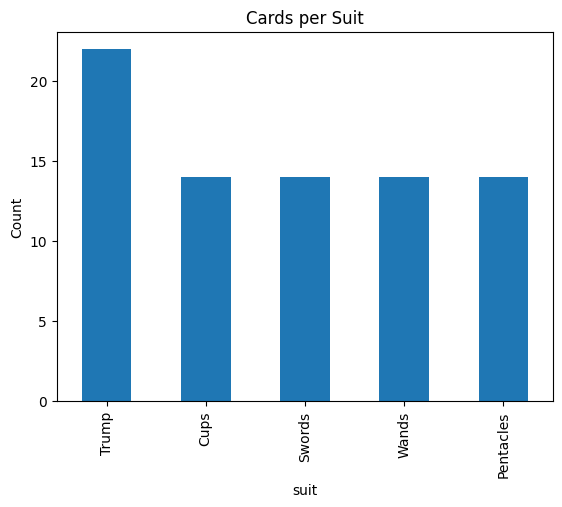

In [ ]:
# quick visualization - cards per suit
import matplotlib.pyplot as plt

tarot_df['suit'].value_counts().plot(kind='bar', title='Cards per Suit')
plt.ylabel('Count')
plt.show()

In [ ]:
hand_df = pd.read_csv('/content/palm_images/HandInfo.csv')
print("Rows:", hand_df.shape[0])
print("Columns:", hand_df.shape[1])
print(hand_df.columns.tolist())
hand_df.head()

Rows: 11076
Columns: 9
['id', 'age', 'gender', 'skinColor', 'accessories', 'nailPolish', 'aspectOfHand', 'imageName', 'irregularities']


,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0


In [ ]:
hand_df.info()
print("\nMissing values:\n", hand_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11076 entries, 0 to 11075
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              11076 non-null  int64 
 1   age             11076 non-null  int64 
 2   gender          11076 non-null  object
 3   skinColor       11076 non-null  object
 4   accessories     11076 non-null  int64 
 5   nailPolish      11076 non-null  int64 
 6   aspectOfHand    11076 non-null  object
 7   imageName       11076 non-null  object
 8   irregularities  11076 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 778.9+ KB

Missing values:
 id                0
age               0
gender            0
skinColor         0
accessories       0
nailPolish        0
aspectOfHand      0
imageName         0
irregularities    0
dtype: int64


In [ ]:
import os

image_count = 0
for root, dirs, files in os.walk('/content/palm_images/Hands'):
    image_count += len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

print("Total hand images (recursive):", image_count)
print("Rows in CSV:", hand_df.shape[0])

Total hand images (recursive): 11076
Rows in CSV: 11076


In [ ]:
print(hand_df['age'].describe())

count    11076.000000
mean        22.494583
std          6.918974
min         18.000000
25%         21.000000
50%         21.000000
75%         22.000000
max         75.000000
Name: age, dtype: float64


In [ ]:
print(hand_df['gender'].value_counts())

gender
female    7109
male      3967
Name: count, dtype: int64


In [ ]:
print(hand_df['skinColor'].value_counts())

skinColor
medium       6495
fair         3493
dark          758
very fair     330
Name: count, dtype: int64


In [ ]:
print(hand_df['accessories'].value_counts())
print(hand_df['nailPolish'].value_counts())

accessories
0    7865
1    3211
Name: count, dtype: int64
nailPolish
0    10009
1     1067
Name: count, dtype: int64


In [ ]:
print(hand_df['aspectOfHand'].value_counts())

aspectOfHand
dorsal right    2892
palmar right    2813
dorsal left     2788
palmar left     2583
Name: count, dtype: int64


In [ ]:
print(hand_df['irregularities'].value_counts())


irregularities
0    10912
1      164
Name: count, dtype: int64


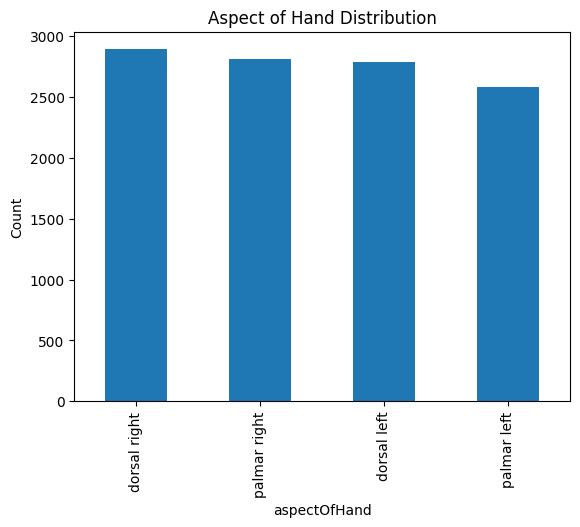

In [ ]:
import matplotlib.pyplot as plt
hand_df['aspectOfHand'].value_counts().plot(kind='bar', title='Aspect of Hand Distribution')
plt.ylabel('Count')
plt.show()

In [ ]:
!pip install mediapipe==0.10.35


In [ ]:
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

In [ ]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
detector = vision.HandLandmarker.create_from_options(options)
print("Detector ready!")

Detector ready!


In [ ]:
import pandas as pd
import os

hand_df = pd.read_csv('/content/palm_images/HandInfo.csv')
palmar_df = hand_df[hand_df['aspectOfHand'].str.contains('palmar')]
print("Palmar images:", palmar_df.shape[0])

image_folder = '/content/palm_images/Hands/Hands'

Palmar images: 5396


In [ ]:
import time

sample_test = palmar_df.sample(50, random_state=42)
start = time.time()

for fname in sample_test['imageName']:
    path = os.path.join(image_folder, fname)
    img = mp.Image.create_from_file(path)
    result = detector.detect(img)

elapsed = time.time() - start
per_image = elapsed / 50
print(f"Time for 50 images: {elapsed:.1f}s")
print(f"Per image: {per_image:.3f}s")
print(f"Estimated time for all {palmar_df.shape[0]} images: {per_image * palmar_df.shape[0] / 60:.1f} minutes")

Time for 50 images: 3.5s
Per image: 0.070s
Estimated time for all 5396 images: 6.3 minutes


In [ ]:
import pandas as pd

rows = []

for fname in palmar_df['imageName']:
    path = os.path.join(image_folder, fname)
    img = mp.Image.create_from_file(path)
    result = detector.detect(img)

    if result.hand_landmarks:
        landmarks = result.hand_landmarks[0]  # first detected hand
        row = {'imageName': fname}
        for i, point in enumerate(landmarks):
            row[f'x{i}'], row[f'y{i}'], row[f'z{i}'] = point.x, point.y, point.z
        rows.append(row)

geometry_df = pd.DataFrame(rows)
print("Images with detected hand landmarks:", geometry_df.shape[0])
print("Out of total palmar images:", palmar_df.shape[0])

Images with detected hand landmarks: 5380
Out of total palmar images: 5396


In [ ]:
geometry_df.to_csv('/content/palm_geometry.csv', index=False)
print("Saved!")

Saved!


In [ ]:
print("Shape:", geometry_df.shape)
print(geometry_df.columns.tolist()[:10], "... (63 landmark columns total)")
geometry_df.describe()

Shape: (5380, 64)
['imageName', 'x0', 'y0', 'z0', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2'] ... (63 landmark columns total)


,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,...,z17,x18,y18,z18,x19,y19,z19,x20,y20,z20
count,5380.000000,5380.000000,5.380000e+03,5380.000000,5380.000000,5380.000000,5380.000000,5380.000000,5380.000000,5380.000000,...,5380.000000,5380.000000,5380.000000,5380.000000,5380.000000,5380.000000,5380.000000,5380.000000,5380.000000,5380.000000
mean,0.555570,0.019233,3.125695e-07,0.542015,0.103356,-0.051640,0.520040,0.238884,-0.071186,0.497444,...,-0.044696,0.501146,0.471753,-0.072156,0.494508,0.551251,-0.089605,0.487005,0.625520,-0.102213
std,0.085301,0.069042,2.491991e-07,0.161745,0.079649,0.014614,0.219002,0.095211,0.024944,0.244861,...,0.030721,0.127006,0.082202,0.039268,0.140237,0.084481,0.043193,0.150317,0.087355,0.045743
min,0.288282,-0.202848,-2.623519e-07,0.138788,-0.115561,-0.140244,0.058700,-0.012445,-0.234454,0.022802,...,-0.271584,0.135897,0.181333,-0.361148,0.102269,0.221562,-0.408308,0.060562,0.264529,-0.444032
25%,0.496952,-0.023307,1.370906e-07,0.402368,0.049306,-0.060194,0.316816,0.171168,-0.085935,0.268464,...,-0.059366,0.390215,0.415581,-0.090947,0.372963,0.494187,-0.111060,0.359986,0.567313,-0.125426
50%,0.543107,0.013890,2.779716e-07,0.515599,0.095539,-0.049703,0.441788,0.239894,-0.067517,0.407330,...,-0.041169,0.520685,0.471401,-0.067081,0.510829,0.550936,-0.083358,0.500874,0.626278,-0.095384
75%,0.600515,0.053609,4.471622e-07,0.677750,0.145886,-0.041145,0.722113,0.294652,-0.053866,0.724564,...,-0.026387,0.601977,0.526577,-0.048160,0.604413,0.611049,-0.062839,0.602491,0.688891,-0.073806
max,0.891601,0.312019,1.443442e-06,0.946781,0.430797,-0.006476,0.985538,0.583117,-0.000919,1.030458,...,0.060397,0.830114,0.726273,0.079891,0.867080,0.808043,0.087992,0.898918,0.888152,0.091468


In [ ]:
import matplotlib.pyplot as plt
import cv2

# MediaPipe hand connections (which points connect to which, for drawing the "skeleton")
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),        # thumb
    (0,5),(5,6),(6,7),(7,8),        # index
    (5,9),(9,10),(10,11),(11,12),   # middle
    (9,13),(13,14),(14,15),(15,16), # ring
    (13,17),(17,18),(18,19),(19,20),# pinky
    (0,17)                          # palm base
]

def show_landmarks(fname, image_folder):
    path = os.path.join(image_folder, fname)
    img = mp.Image.create_from_file(path)
    result = detector.detect(img)

    cv_img = cv2.cvtColor(img.numpy_view(), cv2.COLOR_RGB2BGR)
    h, w, _ = cv_img.shape

    if result.hand_landmarks:
        landmarks = result.hand_landmarks[0]
        points = [(int(pt.x * w), int(pt.y * h)) for pt in landmarks]

        for start, end in HAND_CONNECTIONS:
            cv2.line(cv_img, points[start], points[end], (0, 255, 0), 2)
        for pt in points:
            cv2.circle(cv_img, pt, 4, (0, 0, 255), -1)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(fname)
    plt.show()

In [ ]:
sample_names = geometry_df['imageName'].sample(4, random_state=1).tolist()

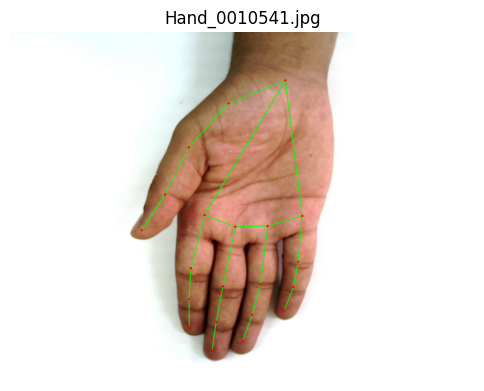

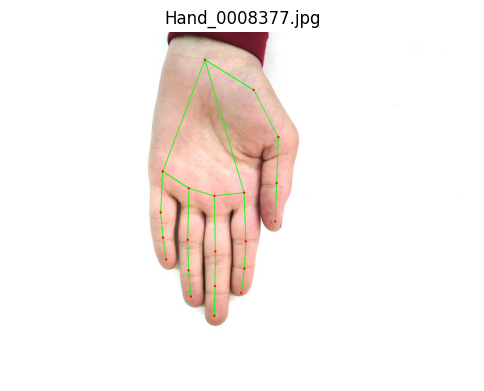

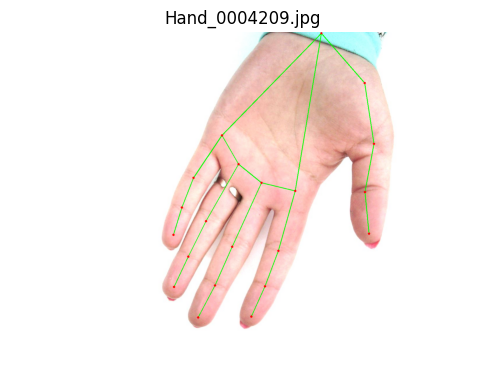

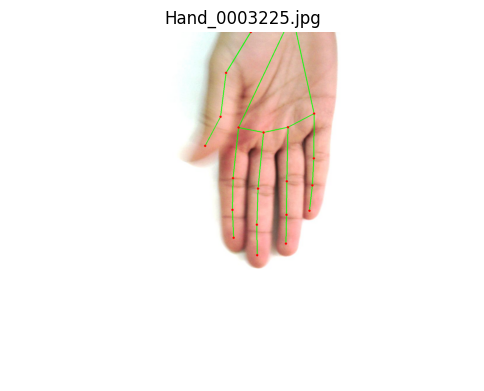

In [ ]:
for name in sample_names:
    show_landmarks(name, image_folder)